In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")


## Data Loading

In [2]:
regression_dataset = pd.read_csv('../data/processed/regression_dataset.csv')

## Split features & target

In [3]:
production_features = [
    'Prod_Grains', 'Prod_Roots_&_Tubers', 'Prod_Sugars', 'Prod_Pulses',
    'Prod_Nuts_&_Seeds', 'Prod_Vegetables', 'Prod_Fruits', 'Prod_Oils',
    'Prod_Meat___High_Impact', 'Prod_Meat___Medium_Impact',
    'Prod_Dairy_&_Eggs', 'Prod_Seafood', 'Prod_Other'
]

# Define target (y)
target = 'Emissions_MtCO2eq'

In [4]:
# Check for missing values
print("Missing values in features:")
for feat in production_features:
    missing = regression_dataset[feat].isna().sum()
    if missing > 0:
        print(f"  {feat}: {missing} missing values")
        regression_dataset[feat] = regression_dataset[feat].fillna(0)

print(f"\nTarget column '{target}' - no missing values: {regression_dataset[target].isna().sum() == 0}")

# Remove rows with zero target (no production data)
regression_dataset = regression_dataset[regression_dataset[target] > 0]
print(f"After removing zero-emission rows: {len(regression_dataset)} rows")

Missing values in features:

Target column 'Emissions_MtCO2eq' - no missing values: True
After removing zero-emission rows: 14045 rows


In [5]:
print(regression_dataset['Emissions_MtCO2eq'].describe())

count    14045.000000
mean      1116.736750
std       4878.801121
min          0.000857
25%          5.676925
50%         56.752089
75%        376.751259
max      92857.918114
Name: Emissions_MtCO2eq, dtype: float64


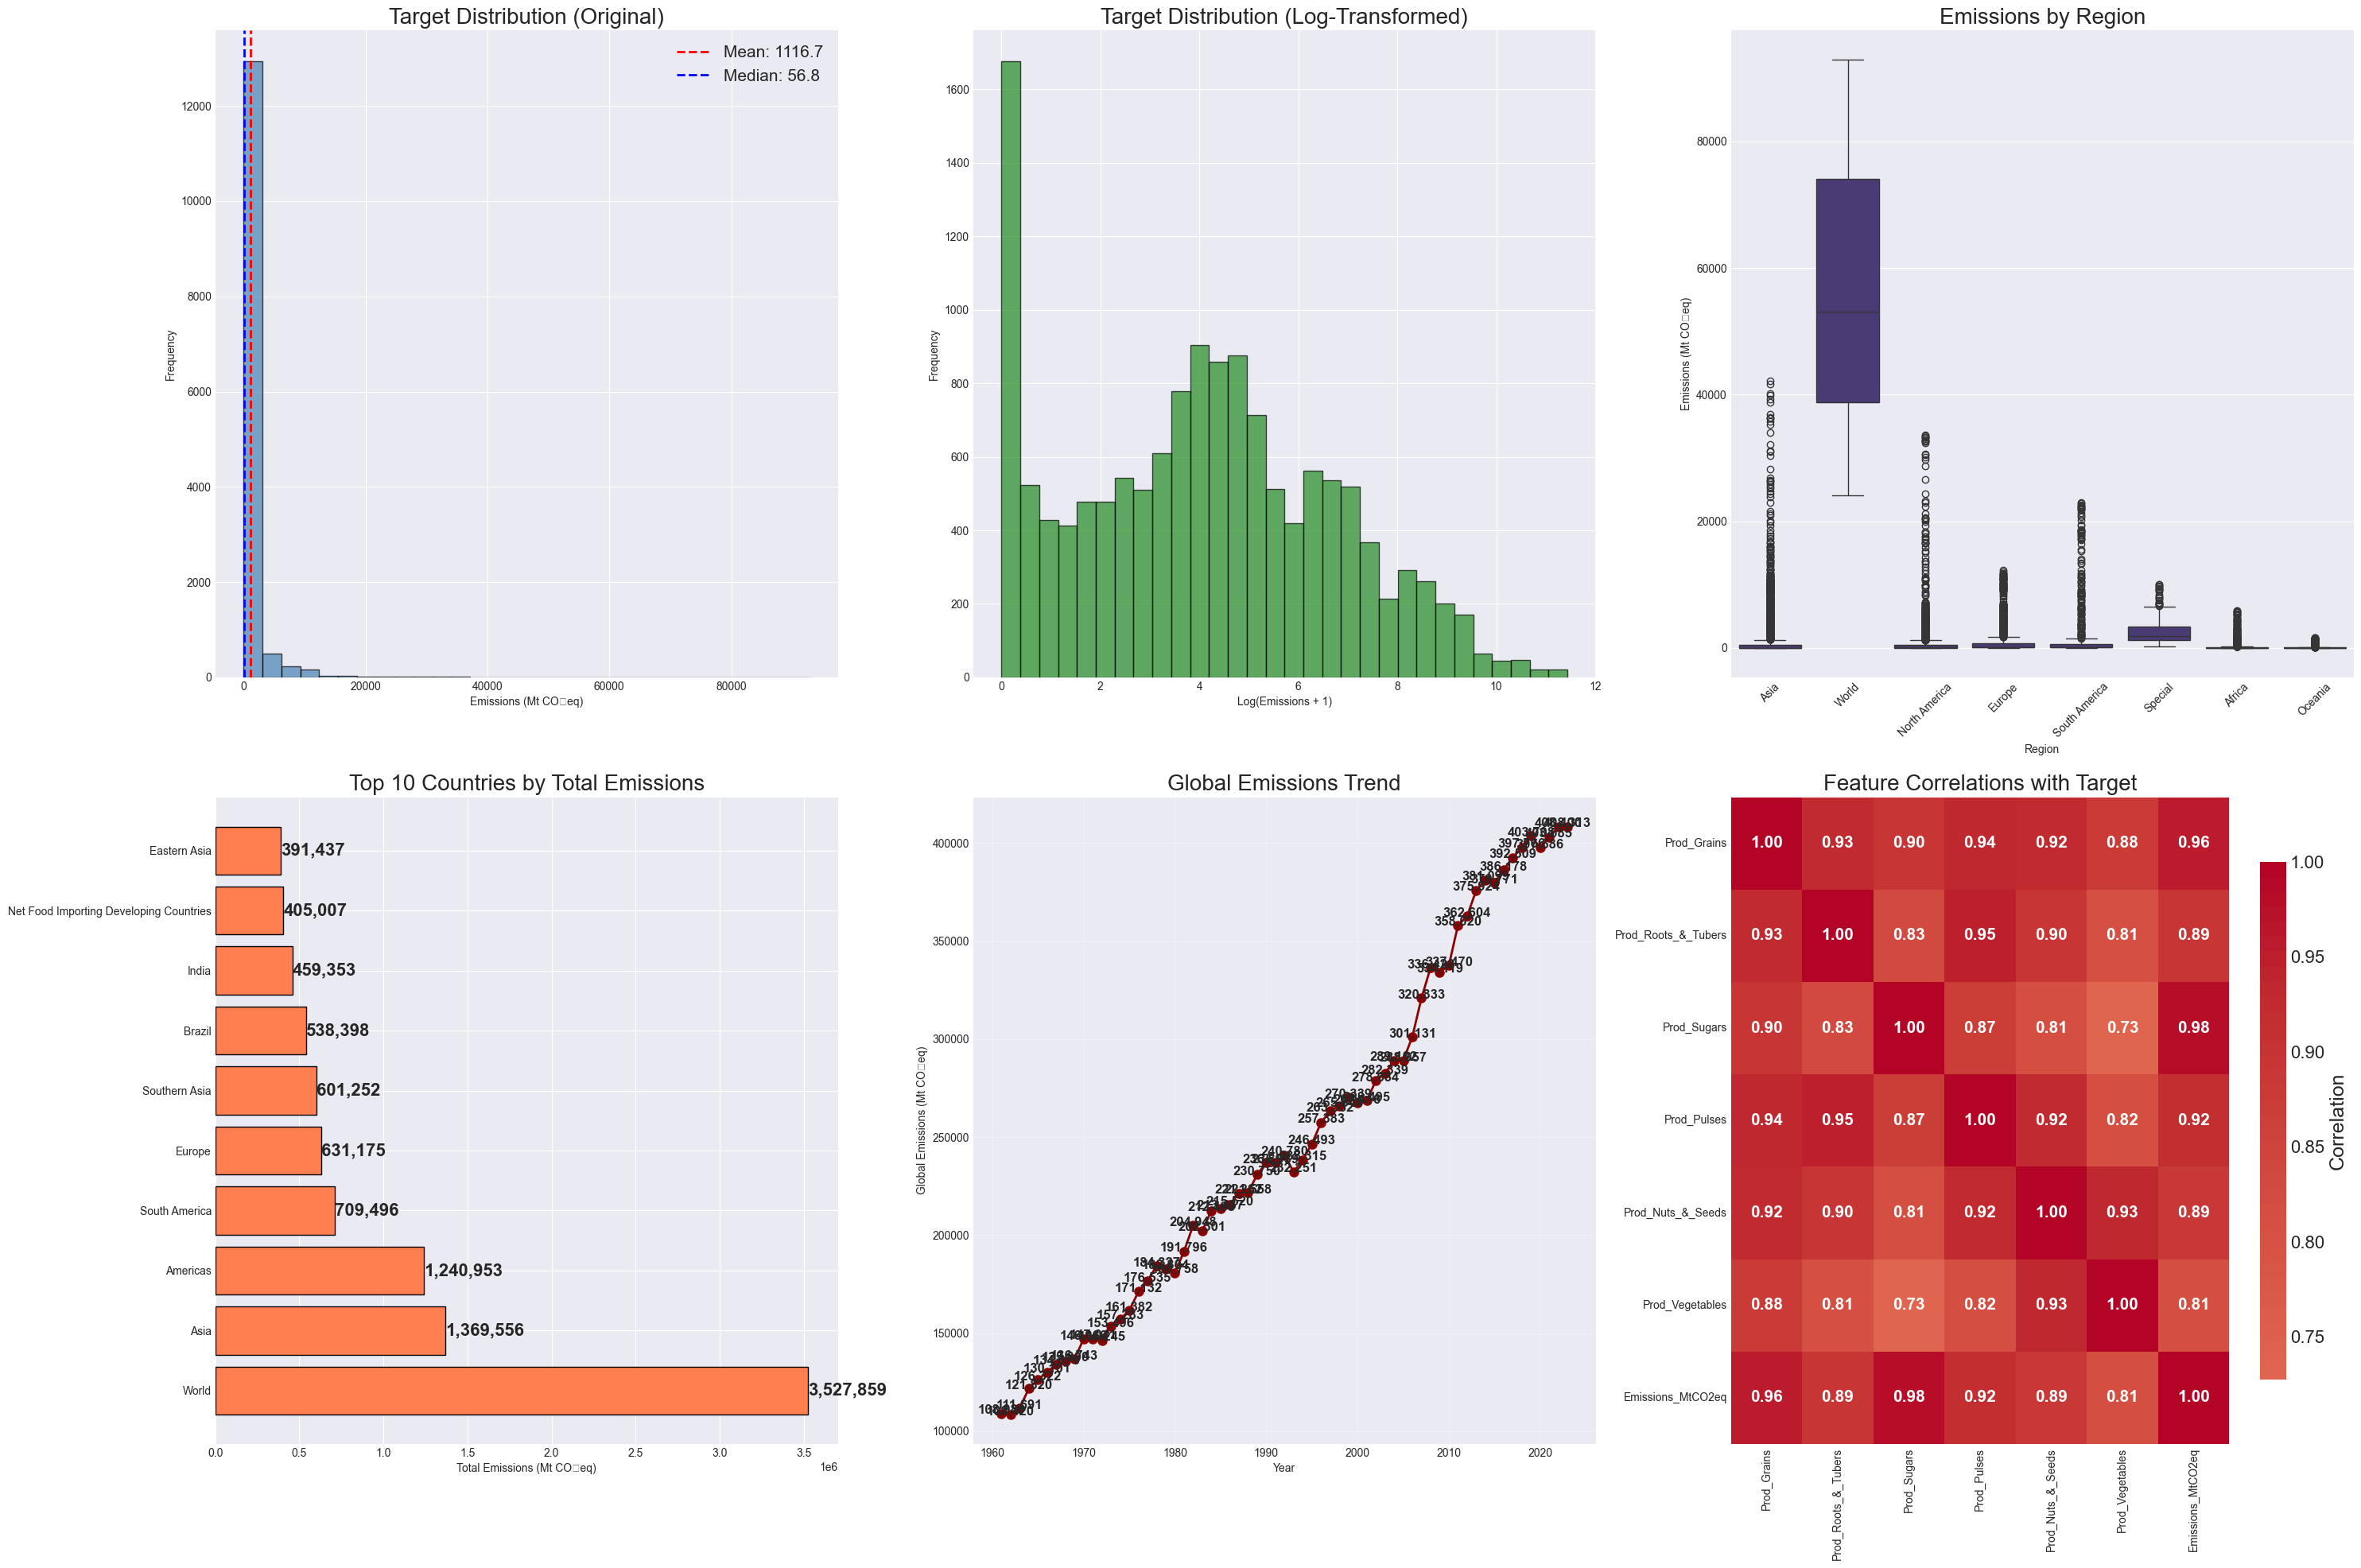

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(30, 20))

# Set all fonts at once using rcParams
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 15,
})

# 1. Original distribution
axes[0,0].hist(regression_dataset[target], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].set_xlabel('Emissions (Mt CO₂eq)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Target Distribution (Original)')
axes[0,0].axvline(regression_dataset[target].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {regression_dataset[target].mean():.1f}')
axes[0,0].axvline(regression_dataset[target].median(), color='blue', linestyle='--', linewidth=2,
                   label=f'Median: {regression_dataset[target].median():.1f}')
axes[0,0].legend()

# 2. Log-transformed distribution
log_target = np.log1p(regression_dataset[target])
axes[0,1].hist(log_target, bins=30, edgecolor='black', alpha=0.7, color='forestgreen')
axes[0,1].set_xlabel('Log(Emissions + 1)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Target Distribution (Log-Transformed)')

# 3. Boxplot by region
region_order = regression_dataset.groupby('Region')[target].sum().sort_values(ascending=False).index
sns.boxplot(data=regression_dataset, x='Region', y=target, order=region_order, ax=axes[0,2])
axes[0,2].set_title('Emissions by Region')
axes[0,2].set_xlabel('Region')
axes[0,2].set_ylabel('Emissions (Mt CO₂eq)')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Top 10 countries
top_countries = regression_dataset.groupby('Area')[target].sum().sort_values(ascending=False).head(10)
axes[1,0].barh(range(len(top_countries)), top_countries.values, color='coral', edgecolor='black')
axes[1,0].set_yticks(range(len(top_countries)))
axes[1,0].set_yticklabels(top_countries.index)
axes[1,0].set_xlabel('Total Emissions (Mt CO₂eq)')
axes[1,0].set_title('Top 10 Countries by Total Emissions')
# Add labels
for i, v in enumerate(top_countries.values):
    axes[1,0].text(v + 10, i, f'{v:,.0f}', va='center', fontweight='bold')

# 5. Emissions over time
yearly_total = regression_dataset.groupby('Year')[target].sum()
axes[1,1].plot(yearly_total.index, yearly_total.values, marker='o', linewidth=2, markersize=8, color='darkred')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Global Emissions (Mt CO₂eq)')
axes[1,1].set_title('Global Emissions Trend')
axes[1,1].grid(True, alpha=0.3)
# Add labels
for idx, val in enumerate(yearly_total.values):
    axes[1,1].text(yearly_total.index[idx], val + 30, f'{val:,.0f}',
                   ha='center', fontsize=12, fontweight='bold')

# 6. Correlation heatmap
top_prod_features = production_features[:6]
corr_matrix = regression_dataset[top_prod_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 15, 'weight': 'bold'},
            ax=axes[1,2],
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
axes[1,2].set_title('Feature Correlations with Target')

plt.tight_layout()
plt.savefig('../outputs/figures/eda_regression_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing

In [7]:
X = regression_dataset[production_features].copy()
log_y = np.log1p(regression_dataset[target])

In [8]:
# # Log-transform skewed features (optional but recommended)
for col in X.columns:
    if X[col].skew() > 2:  # Highly skewed
        X[f'Log_{col}'] = np.log1p(X[col])
        X = X.drop(col, axis=1)

X.isna().sum()


print(f"Final feature set: {X.columns.tolist()}")
print(f"Number of features: {X.shape[1]}")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, log_y, test_size=0.2, random_state=2
)

# Scale features (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Final feature set: ['Prod_Seafood', 'Log_Prod_Grains', 'Log_Prod_Roots_&_Tubers', 'Log_Prod_Sugars', 'Log_Prod_Pulses', 'Log_Prod_Nuts_&_Seeds', 'Log_Prod_Vegetables', 'Log_Prod_Fruits', 'Log_Prod_Oils', 'Log_Prod_Meat___High_Impact', 'Log_Prod_Meat___Medium_Impact', 'Log_Prod_Dairy_&_Eggs', 'Log_Prod_Other']
Number of features: 13

Training set: 11236 rows
Test set: 2809 rows


## TRAIN REGRESSION MODELS

In [9]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    results.append({
        'Model': name,
        'RMSE_Train': rmse_train,
        'RMSE_Test': rmse_test,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'MAE_Test': mae_test
    })

    print(f"\n{name}:")
    print(f"  Train RMSE: {rmse_train:.2f} Mt CO₂eq")
    print(f"  Test RMSE:  {rmse_test:.2f} Mt CO₂eq")
    print(f"  Test R²:    {r2_test:.4f}")
    print(f"  Test MAE:   {mae_test:.2f} Mt CO₂eq")

# Results DataFrame
results_df = pd.DataFrame(results).sort_values('RMSE_Test')
print("\n" + "-" * 60)
print("BEST MODEL SUMMARY")
print("-" * 60)
best_model = results_df.iloc[0]
print(f"Best Model: {best_model['Model']}")
print(f"Test RMSE: {best_model['RMSE_Test']:.2f} Mt CO₂eq")
print(f"Test R²: {best_model['R2_Test']:.4f}")


Linear Regression:
  Train RMSE: 0.89 Mt CO₂eq
  Test RMSE:  0.87 Mt CO₂eq
  Test R²:    0.8869
  Test MAE:   0.66 Mt CO₂eq

Ridge (L2):
  Train RMSE: 0.89 Mt CO₂eq
  Test RMSE:  0.87 Mt CO₂eq
  Test R²:    0.8869
  Test MAE:   0.66 Mt CO₂eq

Lasso (L1):
  Train RMSE: 0.89 Mt CO₂eq
  Test RMSE:  0.87 Mt CO₂eq
  Test R²:    0.8865
  Test MAE:   0.66 Mt CO₂eq

Random Forest:
  Train RMSE: 0.02 Mt CO₂eq
  Test RMSE:  0.05 Mt CO₂eq
  Test R²:    0.9996
  Test MAE:   0.03 Mt CO₂eq

Gradient Boosting:
  Train RMSE: 0.13 Mt CO₂eq
  Test RMSE:  0.14 Mt CO₂eq
  Test R²:    0.9971
  Test MAE:   0.10 Mt CO₂eq

------------------------------------------------------------
BEST MODEL SUMMARY
------------------------------------------------------------
Best Model: Random Forest
Test RMSE: 0.05 Mt CO₂eq
Test R²: 0.9996


In [10]:
# Get best model
best_model_obj = models[best_model['Model']]
best_model_obj.fit(X_train_scaled, y_train)
y_pred = best_model_obj.predict(X_test_scaled)

In [11]:
# Convert back to original scale
y_pred_original = np.expm1(y_pred)  # Reverse of log1p
y_test_original = np.expm1(y_test)

# Calculate metrics on ORIGINAL scale (for interpretation)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

print("=" * 60)
print("MODEL WITH LOG-TRANSFORMED TARGET")
print("=" * 60)
print(f"RMSE: {rmse:.2f} Mt CO₂eq")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")  # Mean Absolute Percentage Error



MODEL WITH LOG-TRANSFORMED TARGET
RMSE: 109.36 Mt CO₂eq
R²: 0.9993
MAPE: 4.03%


### VISUALIZE PREDICTIONS

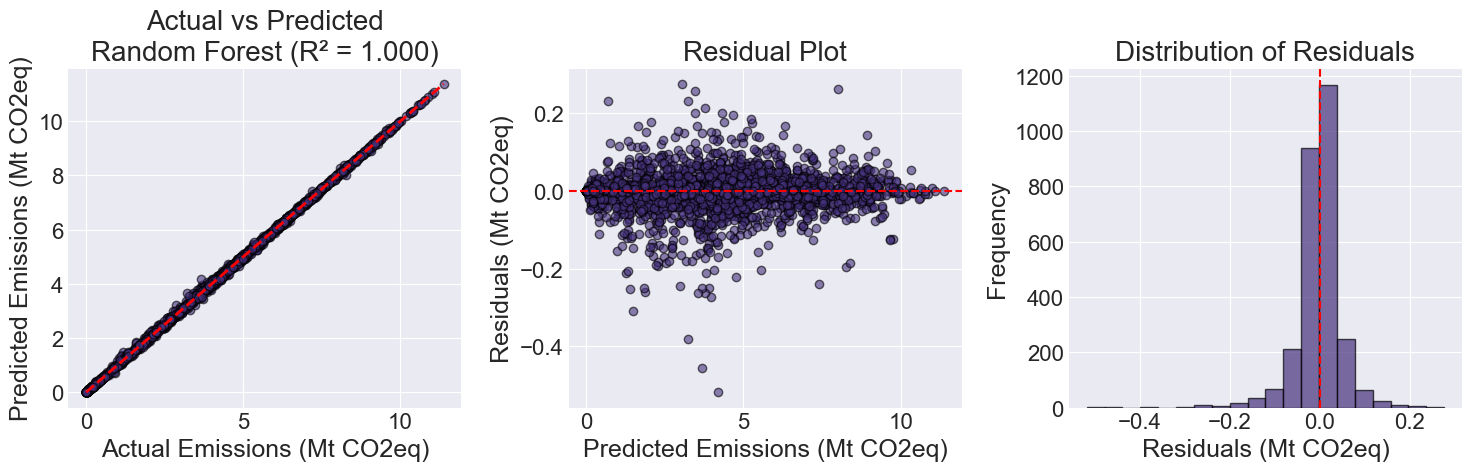

In [12]:

# Create prediction plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Emissions (Mt CO2eq)')
axes[0].set_ylabel('Predicted Emissions (Mt CO2eq)')
axes[0].set_title(f'Actual vs Predicted\n{best_model["Model"]} (R² = {best_model["R2_Test"]:.3f})')

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors='black')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Emissions (Mt CO2eq)')
axes[1].set_ylabel('Residuals (Mt CO2eq)')
axes[1].set_title('Residual Plot')

# Plot 3: Residual distribution
axes[2].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--')
axes[2].set_xlabel('Residuals (Mt CO2eq)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals')

plt.tight_layout()
plt.savefig('../outputs/figures/regression_predictions.png', dpi=150)
plt.show()

### FEATURE IMPORTANCE (Tree-based models)

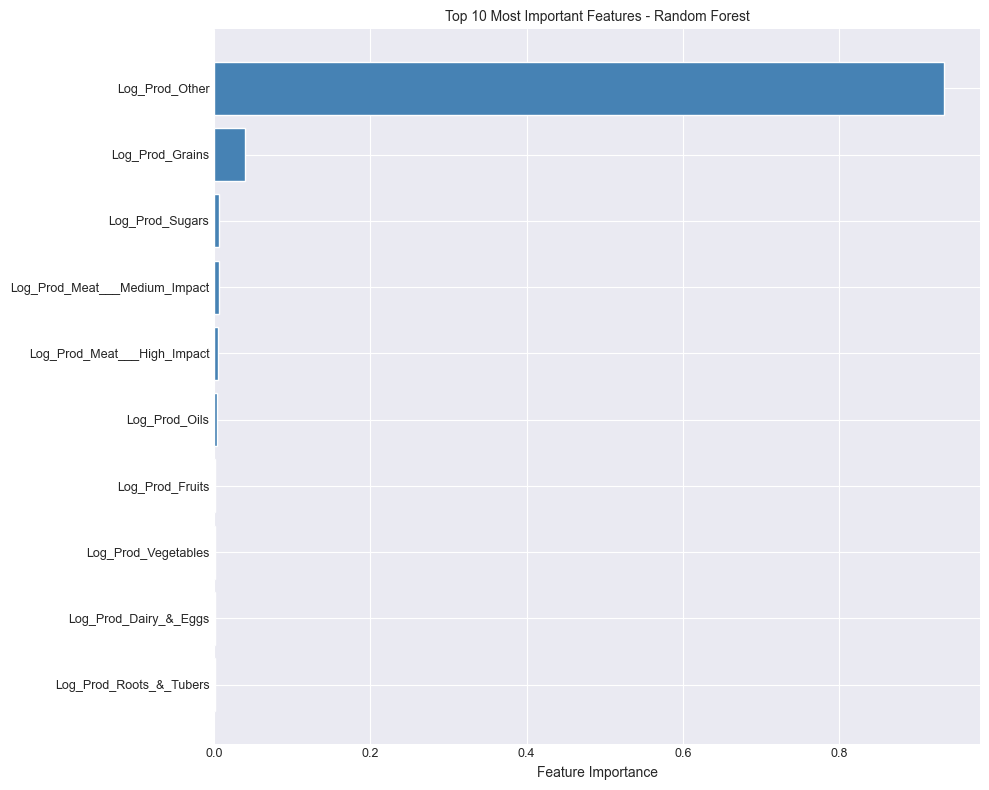


Top 5 most important features:
                      Feature  Importance
               Log_Prod_Other    0.933657
              Log_Prod_Grains    0.039846
              Log_Prod_Sugars    0.005777
Log_Prod_Meat___Medium_Impact    0.005741
  Log_Prod_Meat___High_Impact    0.004741


In [13]:
# Set all fonts at once using rcParams
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
})

if best_model['Model'] in ['Random Forest', 'Gradient Boosting']:
    importances = best_model_obj.feature_importances_
    feature_names = X.columns

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = importance_df.head(10)
    ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 10 Most Important Features - {best_model["Model"]}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
    plt.show()

    print("\nTop 5 most important features:")
    print(importance_df.head().to_string(index=False))


### for all countries

In [14]:
best_model_obj.fit(X_train_scaled, y_train)
all_predictions = best_model_obj.predict(scaler.transform(X)) # [selected_features]

# Convert back to original scale
all_predictions = np.expm1(all_predictions)

regression_dataset['Predicted_Emissions'] = all_predictions
regression_dataset['Prediction_Error'] = regression_dataset['Emissions_MtCO2eq'] - regression_dataset['Predicted_Emissions']


regional_stats = regression_dataset.groupby('Region').agg({
    'Emissions_MtCO2eq': 'mean',
    'Predicted_Emissions': 'mean',
    'Prediction_Error': 'mean'
}).round(2)

print("\nRegional Statistics:")
print(regional_stats)


Regional Statistics:
               Emissions_MtCO2eq  Predicted_Emissions  Prediction_Error
Region                                                                 
Africa                    170.81               170.24              0.57
Asia                     1376.53              1368.03              8.51
Europe                    943.74               947.52             -3.78
North America            1241.31              1240.83              0.48
Oceania                   157.80               157.58              0.22
South America            1640.45              1653.04            -12.59
Special                  2675.90              2672.31              3.59
World                   55997.77             55966.26             31.51


### PROJECT SUMMARY

In [15]:
print(f"""
PROJECT SUMMARY
---------------
Objective: Predict food production emissions at country level using production patterns

Data Coverage:
- Countries analyzed: {len(regression_dataset['Area'].unique())}
- Features used: {X.columns} production categories
- Time period: 2020

MODEL PERFORMANCE
----------------
Best Model: {best_model['Model']}
Test RMSE: {best_model['RMSE_Test']:.2f} Mt CO₂eq
Test R² Score: {best_model['R2_Test']:.3f}

Interpretation:
- RMSE of {best_model['RMSE_Test']:.2f} Mt CO₂eq means typical prediction error is ±{best_model['RMSE_Test']:.2f} Mt
- R² of {best_model['R2_Test']:.3f} indicates {best_model['R2_Test']*100:.1f}% of variance explained by model

""")


PROJECT SUMMARY
---------------
Objective: Predict food production emissions at country level using production patterns

Data Coverage:
- Countries analyzed: 245
- Features used: Index(['Prod_Seafood', 'Log_Prod_Grains', 'Log_Prod_Roots_&_Tubers',
       'Log_Prod_Sugars', 'Log_Prod_Pulses', 'Log_Prod_Nuts_&_Seeds',
       'Log_Prod_Vegetables', 'Log_Prod_Fruits', 'Log_Prod_Oils',
       'Log_Prod_Meat___High_Impact', 'Log_Prod_Meat___Medium_Impact',
       'Log_Prod_Dairy_&_Eggs', 'Log_Prod_Other'],
      dtype='object') production categories
- Time period: 2020

MODEL PERFORMANCE
----------------
Best Model: Random Forest
Test RMSE: 0.05 Mt CO₂eq
Test R² Score: 1.000

Interpretation:
- RMSE of 0.05 Mt CO₂eq means typical prediction error is ±0.05 Mt
- R² of 1.000 indicates 100.0% of variance explained by model


